Cell 1: Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.family': 'serif', 'font.size': 11})
pd.set_option('display.max_columns', 30)

Cell 2 — Load Data and Assign Column Headers

In [2]:
url = ("auto.csv")

column_names = [
    'symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
    'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
    'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
    'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
    'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
    'highway-mpg', 'price'
]

df = pd.read_csv(url, header=None, names=column_names)
print("Dataset loaded successfully.")

Dataset loaded successfully.


Cell 3 — Display Shape and First 10 Rows

In [3]:
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
df.head(10)

Dataset shape: 205 rows x 26 columns



,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,52.0,3053,ohc,five,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


Cell 4 — Descriptive Statistics

In [4]:
# Convert columns containing '?' to numeric for accurate stats
df_numeric = df.copy()
for col in ['price', 'horsepower', 'peak-rpm', 'bore', 'stroke', 'normalized-losses']:
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

key_numeric = ['symboling', 'wheel-base', 'length', 'width', 'height',
               'curb-weight', 'engine-size', 'horsepower', 'peak-rpm',
               'city-mpg', 'highway-mpg', 'price']

desc_stats = df_numeric[key_numeric].agg(['mean', 'median', 'std']).round(2).T
desc_stats.columns = ['Mean', 'Median', 'Std Dev']
print("Descriptive Statistics — Numeric Features")
desc_stats

Descriptive Statistics — Numeric Features


,Mean,Median,Std Dev
symboling,0.83,1.0,1.25
wheel-base,98.76,97.0,6.02
length,174.05,173.2,12.34
width,65.91,65.5,2.15
height,53.72,54.1,2.44
curb-weight,2555.57,2414.0,520.68
engine-size,126.91,120.0,41.64
horsepower,104.26,95.0,39.71
peak-rpm,5125.37,5200.0,479.33
city-mpg,25.22,24.0,6.54


Cell 5 — Data Types and Unique Categorical Values

In [5]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Unique Values in Categorical Columns ===")
categorical_cols = ['make', 'fuel-type', 'aspiration', 'num-of-doors',
                    'body-style', 'drive-wheels', 'engine-location',
                    'engine-type', 'num-of-cylinders', 'fuel-system']

for col in categorical_cols:
    uniques = df[col].unique()
    print(f"\n{col} ({len(uniques)} unique values):")
    print(f"  {sorted(uniques.tolist())}")

=== Data Types ===
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

=== Unique Values in Categorical Columns ===

make (22 unique values):
  ['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury', 'mitsubishi', 'nissan

Cell 6 — Figure 1: Histograms of Price and Horsepower

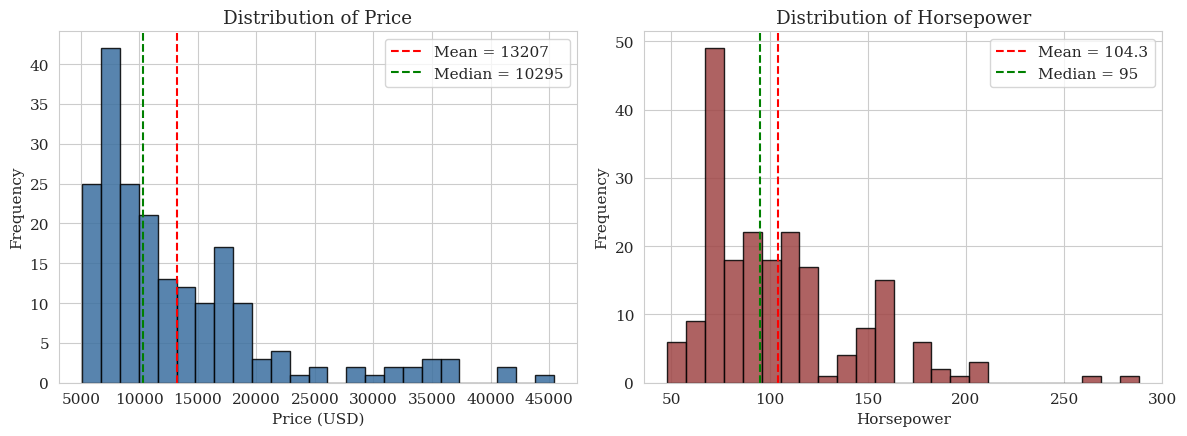

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Price histogram
axes[0].hist(df_numeric['price'].dropna(), bins=25,
             color='#3b6fa0', edgecolor='black', alpha=0.85)
axes[0].axvline(df_numeric['price'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean = {df_numeric["price"].mean():.0f}')
axes[0].axvline(df_numeric['price'].median(), color='green', linestyle='--',
                linewidth=1.5, label=f'Median = {df_numeric["price"].median():.0f}')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Price')
axes[0].legend()

# Horsepower histogram
axes[1].hist(df_numeric['horsepower'].dropna(), bins=25,
             color='#a04646', edgecolor='black', alpha=0.85)
axes[1].axvline(df_numeric['horsepower'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean = {df_numeric["horsepower"].mean():.1f}')
axes[1].axvline(df_numeric['horsepower'].median(), color='green', linestyle='--',
                linewidth=1.5, label=f'Median = {df_numeric["horsepower"].median():.0f}')
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Horsepower')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 7 — Figure 2: Boxplot of Price by Body Style

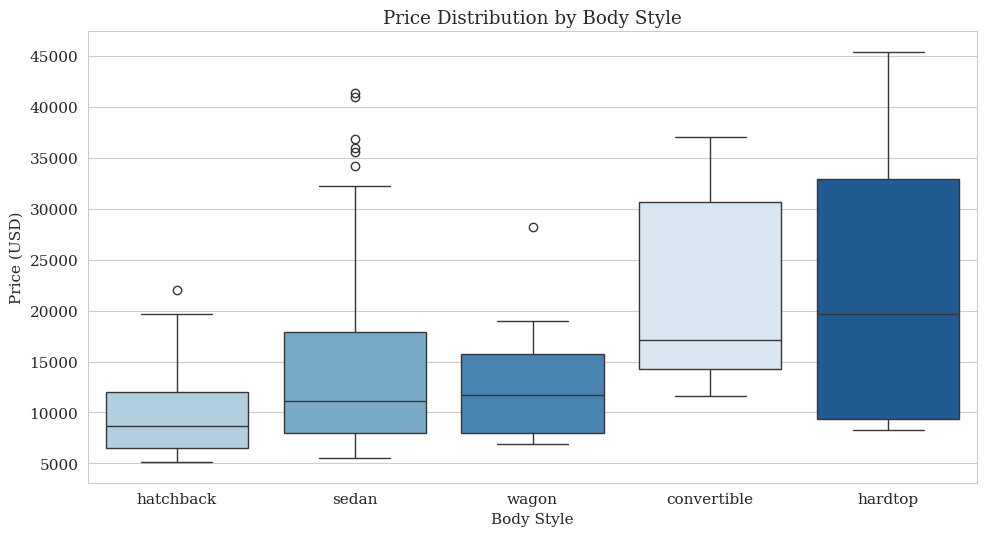

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
order = df_numeric.groupby('body-style')['price'].median().sort_values().index.tolist()
sns.boxplot(data=df_numeric, x='body-style', y='price',
            order=order, hue='body-style', palette='Blues', legend=False, ax=ax)
ax.set_xlabel('Body Style')
ax.set_ylabel('Price (USD)')
ax.set_title('Price Distribution by Body Style')
plt.tight_layout()
plt.savefig('fig2_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 8 — Figure 3: Correlation Heatmap

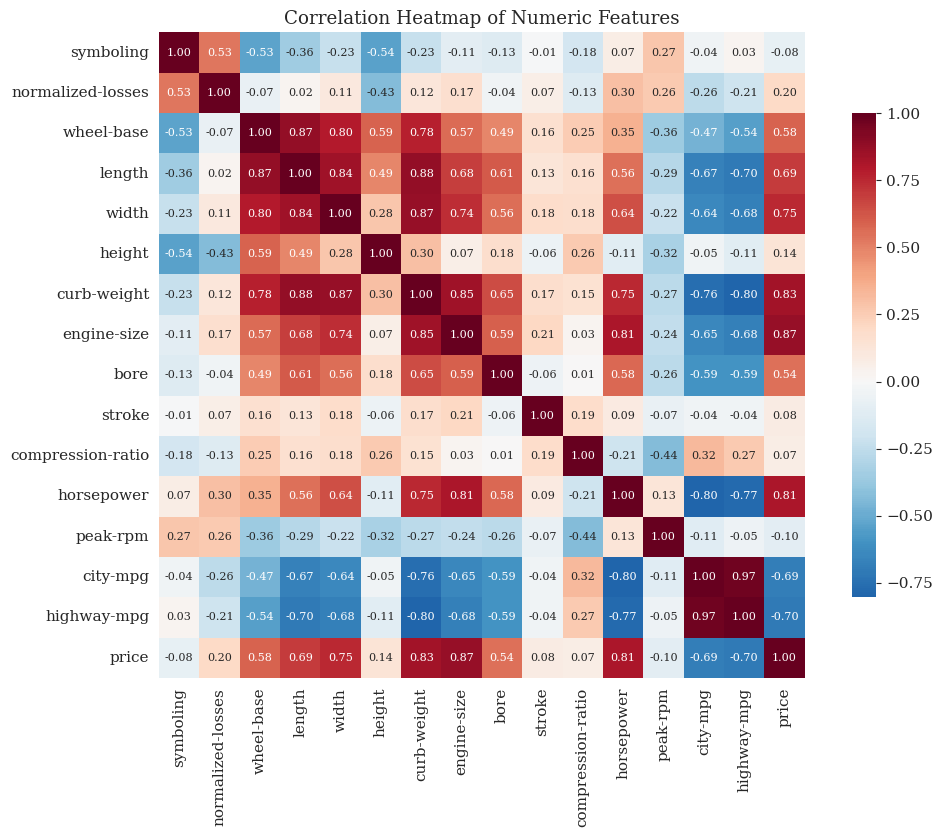


Correlations with Price (sorted by absolute value):
engine-size          0.872
curb-weight          0.834
horsepower           0.811
width                0.751
highway-mpg          0.705
length               0.691
city-mpg             0.687
wheel-base           0.585
bore                 0.543
normalized-losses    0.203
height               0.135
peak-rpm             0.102
symboling            0.082
stroke               0.082
compression-ratio    0.071
Name: price, dtype: float64


In [8]:
numeric_cols = df_numeric.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_numeric[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.75},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('fig3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print sorted correlations with price for the report
print("\nCorrelations with Price (sorted by absolute value):")
print(corr_matrix['price'].drop('price').abs().sort_values(ascending=False).round(3))

Cell 9 —Replace "?" with NaN and Identify Missing Columns

In [9]:
df.replace('?', np.nan, inplace=True)

# Build a missing-values summary table (this becomes Table 2 in the report)
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary = missing_summary.sort_values('Missing Count', ascending=False)

print("=== Table 2: Missing Values Summary ===")
print(f"Total missing entries: {df.isnull().sum().sum()}")
print(f"Columns with missing data: {len(missing_summary)}\n")
missing_summary

=== Table 2: Missing Values Summary ===
Total missing entries: 59
Columns with missing data: 7



,Missing Count,Missing %
normalized-losses,41,20.00
bore,4,1.95
stroke,4,1.95
price,4,1.95
num-of-doors,2,0.98
horsepower,2,0.98
peak-rpm,2,0.98


Cell 10 —Convert Numeric Columns and Apply Imputation

In [10]:
# First convert string columns containing '?' to numeric
numeric_with_missing = ['normalized-losses', 'bore', 'stroke',
                        'horsepower', 'peak-rpm', 'price']
for col in numeric_with_missing:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Mean imputation for numeric predictors
mean_impute_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
print("=== Mean Imputation Values ===")
for col in mean_impute_cols:
    mean_val = df[col].mean()
    print(f"  {col}: {mean_val:.2f}")
    df[col] = df[col].fillna(mean_val)

# Mode imputation for categorical predictor
mode_val = df['num-of-doors'].mode()[0]
print(f"\n=== Mode Imputation ===")
print(f"  num-of-doors: '{mode_val}'")
df['num-of-doors'] = df['num-of-doors'].fillna(mode_val)

# Drop rows with missing target (price)
rows_before = len(df)
df.dropna(subset=['price'], inplace=True)
print(f"\nRows dropped due to missing price: {rows_before - len(df)}")
print(f"Final cleaned shape: {df.shape}")

=== Mean Imputation Values ===
  normalized-losses: 122.00
  bore: 3.33
  stroke: 3.26
  horsepower: 104.26
  peak-rpm: 5125.37

=== Mode Imputation ===
  num-of-doors: 'four'

Rows dropped due to missing price: 4
Final cleaned shape: (201, 26)


Cell 11 —Convert numeric columns and apply mean / mode imputation

In [11]:
df['price'] = df['price'].astype(float)
df['horsepower'] = df['horsepower'].astype(float)

print("Data types after conversion:")
print(f"  price: {df['price'].dtype}")
print(f"  horsepower: {df['horsepower'].dtype}")

Data types after conversion:
  price: float64
  horsepower: float64


Cell 12 —Feature engineering — convert city-mpg to litres per 100 km

In [12]:
df['city-L/100km'] = 235 / df['city-mpg']

print("New feature: city-L/100km")
print(f"  Min: {df['city-L/100km'].min():.2f}")
print(f"  Max: {df['city-L/100km'].max():.2f}")
print(f"  Mean: {df['city-L/100km'].mean():.2f}")
df[['city-mpg', 'city-L/100km']].head()

New feature: city-L/100km
  Min: 4.80
  Max: 18.08
  Mean: 9.94


,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


Cell 13 —Bin horsepower into Low / Medium / High and visualise (Figure 4)

Bin edges: [48.0, 119.3, 190.7, 262.0]

Bin counts:
horsepower-binned
Low       153
Medium     43
High        5


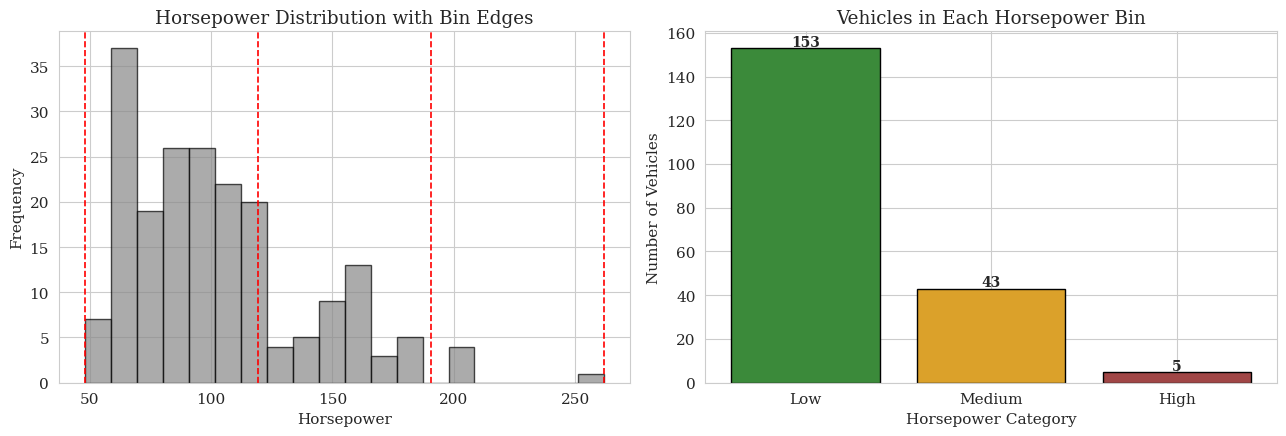

In [13]:
bins = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 4)
labels = ['Low', 'Medium', 'High']
df['horsepower-binned'] = pd.cut(df['horsepower'], bins=bins,
                                  labels=labels, include_lowest=True)

print(f"Bin edges: {bins.round(1).tolist()}")
print("\nBin counts:")
print(df['horsepower-binned'].value_counts().sort_index().to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram with bin edges
axes[0].hist(df['horsepower'], bins=20, color='#888',
             edgecolor='black', alpha=0.7)
for b in bins:
    axes[0].axvline(b, color='red', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Horsepower')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Horsepower Distribution with Bin Edges')

# Right: bar chart of bin counts
counts = df['horsepower-binned'].value_counts().sort_index()
bar_colors = ['#3b8a3a', '#dba12a', '#a04646']
axes[1].bar(counts.index.astype(str), counts.values,
            color=bar_colors, edgecolor='black')
for i, (k, v) in enumerate(counts.items()):
    axes[1].text(i, v + 1, str(v), ha='center',
                 fontsize=10, fontweight='bold')
axes[1].set_xlabel('Horsepower Category')
axes[1].set_ylabel('Number of Vehicles')
axes[1].set_title('Vehicles in Each Horsepower Bin')

plt.tight_layout()
plt.savefig('fig4_binning.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 14 —Min-max normalisation of length, width, height + visualisation (Figure 5)

Normalised features summary:
       length-norm  width-norm  height-norm
count      201.000     201.000      201.000
mean         0.494       0.478        0.497
std          0.184       0.180        0.204
min          0.000       0.000        0.000
25%          0.384       0.325        0.350
50%          0.479       0.444        0.525
75%          0.633       0.538        0.642
max          1.000       1.000        1.000


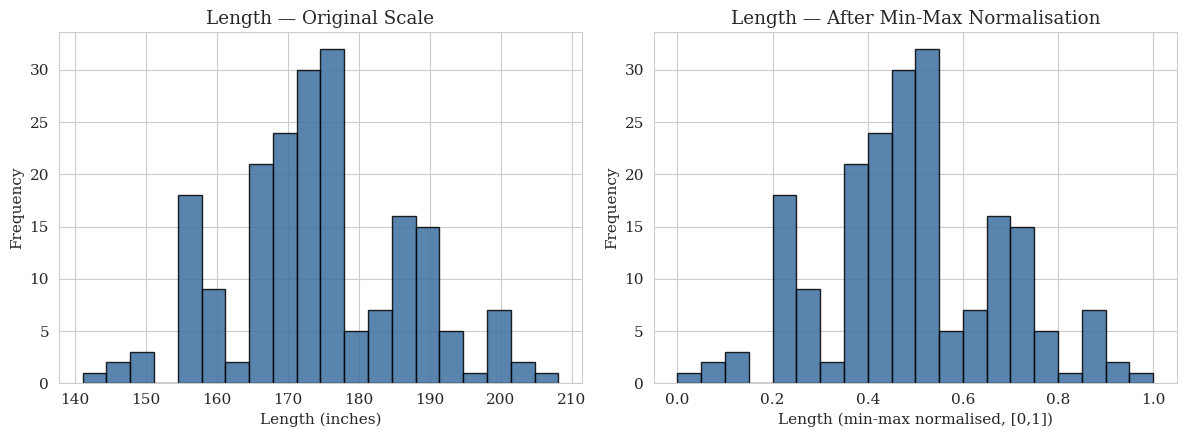


Final dataset shape (with engineered features): (201, 31)
Dataset saved as 'auto_cleaned.csv' — will be used in Task 3.


In [14]:
for col in ['length', 'width', 'height']:
    df[f'{col}-norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

print("Normalised features summary:")
print(df[['length-norm', 'width-norm', 'height-norm']].describe().round(3))

# Visualisation: before vs after for length
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df['length'], bins=20, color='#3b6fa0',
             edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Length (inches)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Length — Original Scale')

axes[1].hist(df['length-norm'], bins=20, color='#3b6fa0',
             edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Length (min-max normalised, [0,1])')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Length — After Min-Max Normalisation')

plt.tight_layout()
plt.savefig('fig5_normalisation.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the cleaned, engineered dataset for use in Task 3 onwards
df.to_csv('auto_cleaned.csv', index=False)
print(f"\nFinal dataset shape (with engineered features): {df.shape}")
print("Dataset saved as 'auto_cleaned.csv' — will be used in Task 3.")

Cell 15 — Imports and Feature Selection

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Helper function for evaluation
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{name}: R2={r2:.4f}, MAE=${mae:.2f}, MSE={mse:.2f}, RMSE=${rmse:.2f}")
    return {'Model': name, 'R2': round(r2, 4), 'MAE': round(mae, 2),
            'MSE': round(mse, 2), 'RMSE': round(rmse, 2)}

# Select numeric features for regression
features = ['engine-size', 'curb-weight', 'horsepower', 'width', 'length',
            'wheel-base', 'highway-mpg', 'city-L/100km',
            'bore', 'stroke', 'compression-ratio']
X = df[features].copy()
y = df['price'].copy()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"Features used:\n  {features}")

Feature matrix X shape: (201, 11)
Target vector y shape: (201,)
Features used:
  ['engine-size', 'curb-weight', 'horsepower', 'width', 'length', 'wheel-base', 'highway-mpg', 'city-L/100km', 'bore', 'stroke', 'compression-ratio']


Cell 16 — Part A: Linear Regression (80/20 split)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Training set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows\n")

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_train_pred = lr.predict(X_train)
lr_test_pred = lr.predict(X_test)

print("=== Linear Regression — 80/20 split ===")
results_list = []
results_list.append(evaluate_model("LR 80/20 (train)", y_train, lr_train_pred))
results_list.append(evaluate_model("LR 80/20 (test)", y_test, lr_test_pred))

# Coefficient inspection
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': lr.coef_.round(2)})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print("\nLinear Regression coefficients (sorted by |value|):")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {lr.intercept_:.2f}")

Training set: 160 rows | Test set: 41 rows

=== Linear Regression — 80/20 split ===
LR 80/20 (train): R2=0.8642, MAE=$1785.11, MSE=6194037.08, RMSE=$2488.78
LR 80/20 (test): R2=0.7898, MAE=$3520.75, MSE=25713443.48, RMSE=$5070.84

Linear Regression coefficients (sorted by |value|):
          Feature  Coefficient
           stroke     -1833.63
     city-L/100km      1561.84
             bore      -744.87
            width       391.21
compression-ratio       263.34
      highway-mpg       209.75
       wheel-base       207.00
      engine-size        79.14
           length       -37.41
       horsepower        17.72
      curb-weight        -1.03

Intercept: -52210.92


Cell 17 — Part B: Random Forest (80/20 split) + Figure 6

=== Random Forest Regressor — 80/20 split ===
RF 80/20 (train): R2=0.9814, MAE=$604.02, MSE=846987.72, RMSE=$920.32
RF 80/20 (test): R2=0.9368, MAE=$1771.33, MSE=7730556.95, RMSE=$2780.39


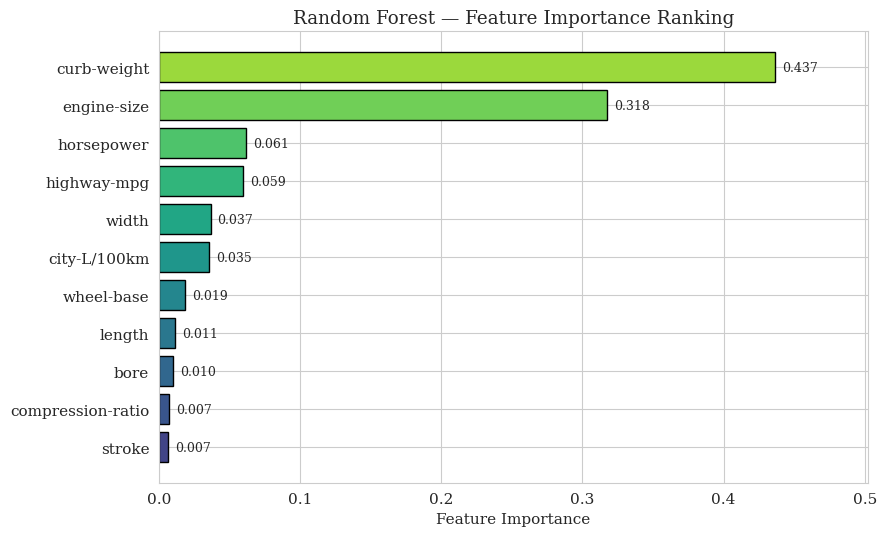


Models saved (will be reused in Tasks 4 and 5).


In [17]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

print("=== Random Forest Regressor — 80/20 split ===")
results_list.append(evaluate_model("RF 80/20 (train)", y_train, rf_train_pred))
results_list.append(evaluate_model("RF 80/20 (test)", y_test, rf_test_pred))

# Feature importance — Figure 6
imp_df = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(imp_df)))
bars = ax.barh(imp_df['feature'], imp_df['importance'], color=colors, edgecolor='black')
for bar, val in zip(bars, imp_df['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Feature Importance Ranking')
ax.set_xlim(0, max(imp_df['importance']) * 1.15)
plt.tight_layout()
plt.savefig('fig6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the trained models for use in Tasks 4 and 5
import pickle
with open('lr_model.pkl', 'wb') as f:
    pickle.dump({'model': lr, 'X_train': X_train, 'X_test': X_test,
                 'y_train': y_train, 'y_test': y_test, 'features': features}, f)
with open('rf_model.pkl', 'wb') as f:
    pickle.dump({'model': rf, 'X_train': X_train, 'X_test': X_test,
                 'y_train': y_train, 'y_test': y_test, 'features': features}, f)
print("\nModels saved (will be reused in Tasks 4 and 5).")

Cell 18 — Part C: 70/30 Split Experimentation

In [18]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.30, random_state=42
)
print(f"Training set: {X_train2.shape[0]} rows | Test set: {X_test2.shape[0]} rows\n")

# Linear Regression on 70/30
lr_70 = LinearRegression()
lr_70.fit(X_train2, y_train2)
lr_70_pred = lr_70.predict(X_test2)

# Random Forest on 70/30
rf_70 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_70.fit(X_train2, y_train2)
rf_70_pred = rf_70.predict(X_test2)

print("=== 70/30 Split Results ===")
results_list.append(evaluate_model("LR 70/30 (test)", y_test2, lr_70_pred))
results_list.append(evaluate_model("RF 70/30 (test)", y_test2, rf_70_pred))

Training set: 140 rows | Test set: 61 rows

=== 70/30 Split Results ===
LR 70/30 (test): R2=0.7977, MAE=$2914.05, MSE=19176991.52, RMSE=$4379.15
RF 70/30 (test): R2=0.9313, MAE=$1643.45, MSE=6515682.14, RMSE=$2552.58


Cell 19 — Table 3 Summary + Figure 7 Comparison

=== Table 3: Model Performance Comparison (Test-set metrics) ===
   Model     R2     MAE         MSE    RMSE
LR 80/20 0.7898 3520.75 25713443.48 5070.84
RF 80/20 0.9368 1771.33  7730556.95 2780.39
LR 70/30 0.7977 2914.05 19176991.52 4379.15
RF 70/30 0.9313 1643.45  6515682.14 2552.58


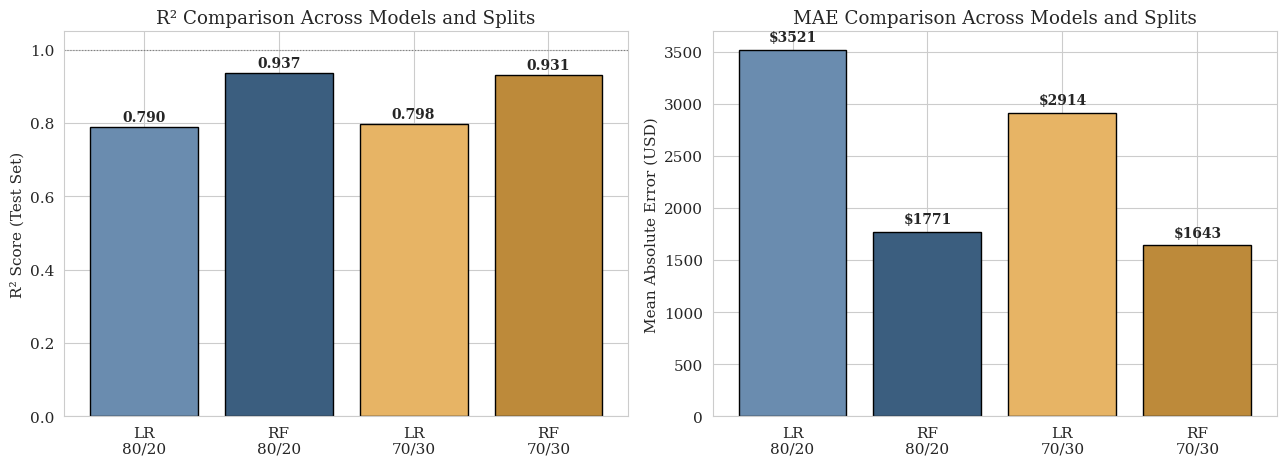

In [19]:
# Table 3 — only test-set rows for the report
results_df = pd.DataFrame(results_list)
table3 = results_df[results_df['Model'].str.contains('test')].copy()
table3['Model'] = table3['Model'].str.replace(' (test)', '', regex=False)
table3 = table3[['Model', 'R2', 'MAE', 'MSE', 'RMSE']].reset_index(drop=True)
print("=== Table 3: Model Performance Comparison (Test-set metrics) ===")
print(table3.to_string(index=False))

# Figure 7 — visual side-by-side comparison
configs = ['LR\n80/20', 'RF\n80/20', 'LR\n70/30', 'RF\n70/30']
r2_scores = [r2_score(y_test, lr_test_pred),
             r2_score(y_test, rf_test_pred),
             r2_score(y_test2, lr_70_pred),
             r2_score(y_test2, rf_70_pred)]
mae_scores = [mean_absolute_error(y_test, lr_test_pred),
              mean_absolute_error(y_test, rf_test_pred),
              mean_absolute_error(y_test2, lr_70_pred),
              mean_absolute_error(y_test2, rf_70_pred)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bar_colors = ['#6a8caf', '#3b5e7f', '#e7b465', '#bd8a3a']

b1 = axes[0].bar(configs, r2_scores, color=bar_colors, edgecolor='black')
for bar, val in zip(b1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.015,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('R² Score (Test Set)')
axes[0].set_title('R² Comparison Across Models and Splits')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=1.0, color='grey', linestyle=':', linewidth=0.8)

b2 = axes[1].bar(configs, mae_scores, color=bar_colors, edgecolor='black')
for bar, val in zip(b2, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 80,
                 f'${val:.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (USD)')
axes[1].set_title('MAE Comparison Across Models and Splits')

plt.tight_layout()
plt.savefig('fig7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 20 — Imports and Price Categorisation

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

# Convert continuous price into 3 quantile-based categories
df['price-category'] = pd.qcut(df['price'], 3, labels=['Low', 'Medium', 'High'])

# Inspect class distribution and cut-points
print("=== Price Category Distribution ===")
print(df['price-category'].value_counts().sort_index())
print(f"\nTotal vehicles: {len(df)}")

q_low = df['price'].quantile(1/3)
q_high = df['price'].quantile(2/3)
print(f"\nQuantile cut-points:")
print(f"  Low:    price <= ${q_low:,.0f}")
print(f"  Medium: ${q_low:,.0f} < price <= ${q_high:,.0f}")
print(f"  High:   price > ${q_high:,.0f}")

=== Price Category Distribution ===
price-category
Low       67
Medium    67
High      67
Name: count, dtype: int64

Total vehicles: 201

Quantile cut-points:
  Low:    price <= $8,322
  Medium: $8,322 < price <= $13,850
  High:   price > $13,850


Cell 21 — Train Logistic Regression with Stratified 80/20 Split

In [21]:
# Reuse the 11 features from Task 3
features_clf = ['engine-size', 'curb-weight', 'horsepower', 'width', 'length',
                'wheel-base', 'highway-mpg', 'city-L/100km',
                'bore', 'stroke', 'compression-ratio']
X_clf = df[features_clf].copy()
y_clf = df['price-category'].copy()

# Standardise features (important for logistic regression)
scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)

# Stratified split preserves class proportions in train and test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)
print(f"Training set: {X_train_clf.shape[0]} rows")
print(f"Test set:     {X_test_clf.shape[0]} rows")

# Fit logistic regression (multinomial by default with newer scikit-learn)
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_clf, y_train_clf)

# Predictions
y_train_pred_clf = logreg.predict(X_train_clf)
y_test_pred_clf = logreg.predict(X_test_clf)

print(f"\nTraining accuracy: {accuracy_score(y_train_clf, y_train_pred_clf):.4f}")
print(f"Test accuracy:     {accuracy_score(y_test_clf, y_test_pred_clf):.4f}")

Training set: 160 rows
Test set:     41 rows

Training accuracy: 0.8438
Test accuracy:     0.9024


Cell 22 — Confusion Matrix + Figure 8

=== Confusion Matrix (Test Set) ===
               Predicted Low  Predicted Medium  Predicted High
Actual Low                13                 1               0
Actual Medium              0                12               2
Actual High                0                 1              12


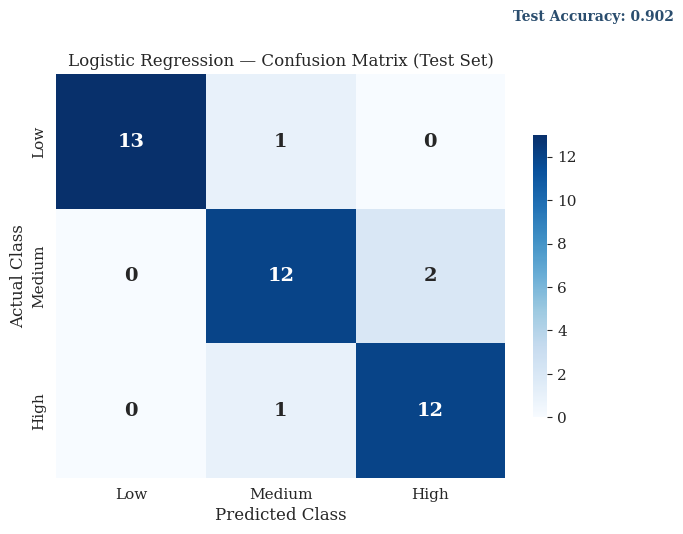

In [22]:
class_labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test_clf, y_test_pred_clf, labels=class_labels)

print("=== Confusion Matrix (Test Set) ===")
cm_df = pd.DataFrame(cm,
                     index=[f'Actual {c}' for c in class_labels],
                     columns=[f'Predicted {c}' for c in class_labels])
print(cm_df)

# Figure 8 — Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'shrink': 0.7},
            annot_kws={'size': 14, 'fontweight': 'bold'}, ax=ax)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('Actual Class', fontsize=12)
ax.set_title('Logistic Regression — Confusion Matrix (Test Set)', fontsize=12)
ax.text(3.05, -0.4,
        f'Test Accuracy: {accuracy_score(y_test_clf, y_test_pred_clf):.3f}',
        fontsize=10, fontweight='bold', color='#2a4d6e')
plt.tight_layout()
plt.savefig('fig8_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 23 — Per-Class Metrics + Figure 9

=== Classification Report ===
              precision    recall  f1-score   support

        High      0.857     0.923     0.889        13
         Low      1.000     0.929     0.963        14
      Medium      0.857     0.857     0.857        14

    accuracy                          0.902        41
   macro avg      0.905     0.903     0.903        41
weighted avg      0.906     0.902     0.903        41



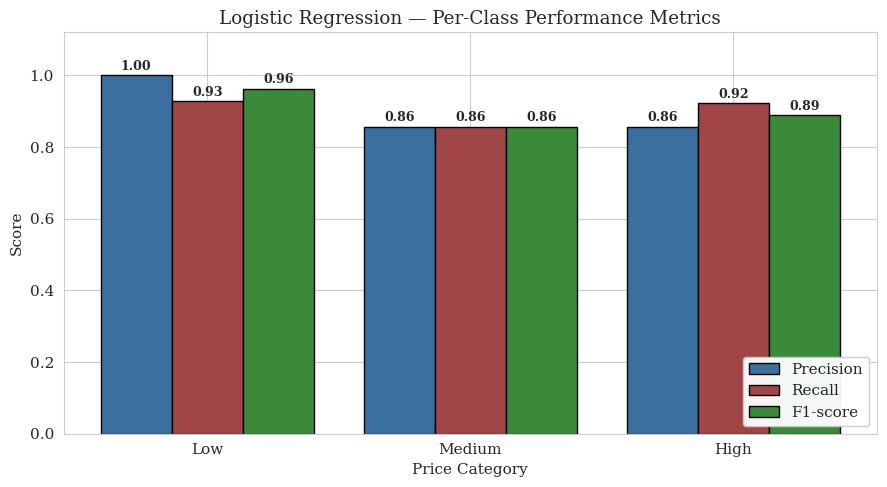


Classifier saved (will be referenced in Task 5).


In [23]:
print("=== Classification Report ===")
print(classification_report(y_test_clf, y_test_pred_clf, digits=3))

# Figure 9 — Per-class precision/recall/F1 bar chart
report = classification_report(y_test_clf, y_test_pred_clf, output_dict=True)
classes = ['Low', 'Medium', 'High']
precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]
f1 = [report[c]['f1-score'] for c in classes]

x = np.arange(len(classes)); w = 0.27
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w, precision, w, label='Precision',
            color='#3b6fa0', edgecolor='black')
b2 = ax.bar(x, recall, w, label='Recall',
            color='#a04646', edgecolor='black')
b3 = ax.bar(x + w, f1, w, label='F1-score',
            color='#3b8a3a', edgecolor='black')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
                f'{h:.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel('Score'); ax.set_xlabel('Price Category')
ax.set_title('Logistic Regression — Per-Class Performance Metrics')
ax.set_ylim(0, 1.12)
ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.savefig('fig9_per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the classifier for use in Task 5 if needed
import pickle
with open('logreg_model.pkl', 'wb') as f:
    pickle.dump({'model': logreg, 'scaler': scaler,
                 'X_train': X_train_clf, 'X_test': X_test_clf,
                 'y_train': y_train_clf, 'y_test': y_test_clf,
                 'features': features_clf}, f)
print("\nClassifier saved (will be referenced in Task 5).")

Cell 24 — Figure 10: Actual vs Predicted

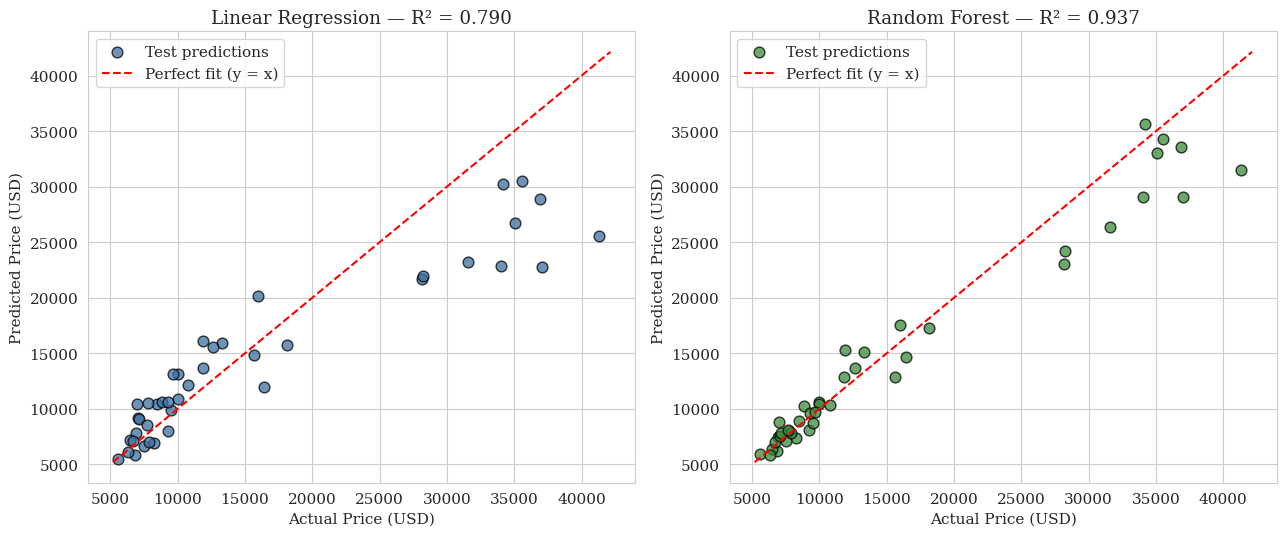

In [24]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
mn = min(y_test.min(), lr_pred.min(), rf_pred.min())
mx = max(y_test.max(), lr_pred.max(), rf_pred.max())
diag = np.linspace(mn * 0.95, mx * 1.02, 100)

# Linear Regression panel
axes[0].scatter(y_test, lr_pred, s=60, c='#3b6fa0',
                edgecolor='black', alpha=0.75, label='Test predictions')
axes[0].plot(diag, diag, 'r--', linewidth=1.5, label='Perfect fit (y = x)')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')
axes[0].set_title(f'Linear Regression — R² = {r2_score(y_test, lr_pred):.3f}')
axes[0].legend(loc='upper left')

# Random Forest panel
axes[1].scatter(y_test, rf_pred, s=60, c='#3b8a3a',
                edgecolor='black', alpha=0.75, label='Test predictions')
axes[1].plot(diag, diag, 'r--', linewidth=1.5, label='Perfect fit (y = x)')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].set_title(f'Random Forest — R² = {r2_score(y_test, rf_pred):.3f}')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('fig10_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 25 — Figure 11: Residual Diagnostic Plots

Linear Regression residuals: mean = $1414, std = $4870
Random Forest residuals:     mean = $873, std = $2640


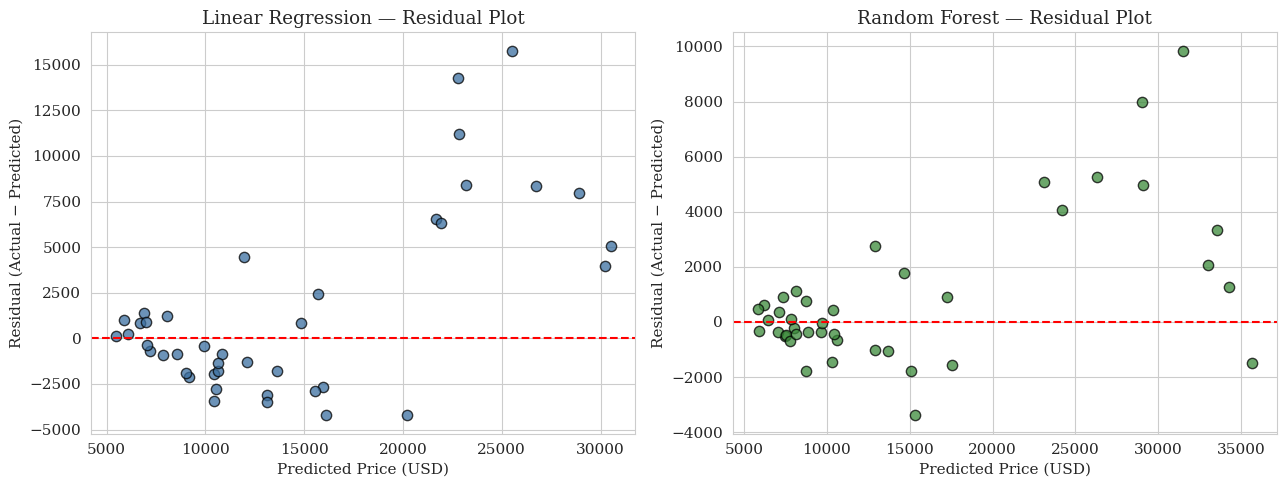

In [25]:
lr_resid = y_test.values - lr_pred
rf_resid = y_test.values - rf_pred

print(f"Linear Regression residuals: mean = ${lr_resid.mean():.0f}, "
      f"std = ${lr_resid.std():.0f}")
print(f"Random Forest residuals:     mean = ${rf_resid.mean():.0f}, "
      f"std = ${rf_resid.std():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(lr_pred, lr_resid, s=55, c='#3b6fa0',
                edgecolor='black', alpha=0.75)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Price (USD)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Linear Regression — Residual Plot')

axes[1].scatter(rf_pred, rf_resid, s=55, c='#3b8a3a',
                edgecolor='black', alpha=0.75)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price (USD)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Random Forest — Residual Plot')

plt.tight_layout()
plt.savefig('fig11_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 26 — Figure 12: Average Feature Profile by Price Tier

=== Average feature values by price tier ===
                curb-weight  engine-size  horsepower  width  city-L/100km
price-category                                                           
Low                 2052.70        96.76       70.94  64.08          7.65
Medium              2521.82       119.58       99.66  65.75          9.87
High                3092.48       164.28      139.61  67.84         12.32

=== Average price by tier ===
                   mean      min      max
price-category                           
Low              6995.0   5118.0   8249.0
Medium          10691.0   8358.0  13845.0
High            21935.0  13860.0  45400.0


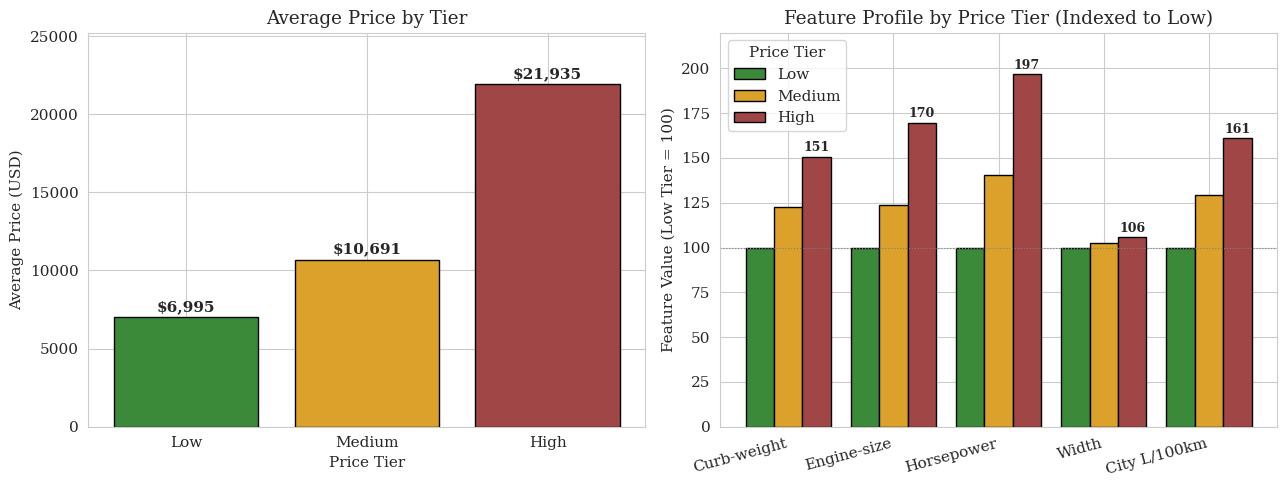

In [26]:
# Cell 26: Figure 12 — Business profile by price tier
# Uses the price-category column created in Task 4 (Cell 20)

key_features_biz = ['curb-weight', 'engine-size', 'horsepower',
                    'width', 'city-L/100km']
profile = df.groupby('price-category', observed=True)[key_features_biz].mean()

print("=== Average feature values by price tier ===")
print(profile.round(2))

print("\n=== Average price by tier ===")
print(df.groupby('price-category', observed=True)['price'].agg(['mean','min','max']).round(0))

# Figure 12 — two-panel summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT panel: Average price by tier
tier_prices = df.groupby('price-category', observed=True)['price'].mean()
tier_colors = ['#3b8a3a', '#dba12a', '#a04646']
bars = axes[0].bar(tier_prices.index.astype(str), tier_prices.values,
                   color=tier_colors, edgecolor='black')
for bar, val in zip(bars, tier_prices.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 400,
                 f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Price (USD)')
axes[0].set_xlabel('Price Tier')
axes[0].set_title('Average Price by Tier')
axes[0].set_ylim(0, max(tier_prices.values) * 1.15)

# RIGHT panel: feature profile indexed to Low = 100
norm = (profile / profile.loc['Low']) * 100
x = np.arange(len(key_features_biz)); w = 0.27
labels_clean = ['Curb-weight', 'Engine-size', 'Horsepower',
                'Width', 'City L/100km']

axes[1].bar(x - w, norm.loc['Low'], w, label='Low',
            color='#3b8a3a', edgecolor='black')
axes[1].bar(x, norm.loc['Medium'], w, label='Medium',
            color='#dba12a', edgecolor='black')
axes[1].bar(x + w, norm.loc['High'], w, label='High',
            color='#a04646', edgecolor='black')
axes[1].axhline(y=100, color='grey', linestyle=':', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_clean, rotation=15, ha='right')
axes[1].set_ylabel('Feature Value (Low Tier = 100)')
axes[1].set_title('Feature Profile by Price Tier (Indexed to Low)')
axes[1].legend(title='Price Tier', loc='upper left')
axes[1].set_ylim(0, 220)

for i, val in enumerate(norm.loc['High'].values):
    axes[1].text(x[i] + w, val + 3, f'{val:.0f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig12_business_profile.png', dpi=150, bbox_inches='tight')
plt.show()